# YOLO 通用训练笔记本（支持 YOLO26 / YOLO11 / YOLOv8）
✅ 本地上传 / Google Drive / Roboflow 三种方式
✅ 一键切换模型版本

## Cell 1 — 检查环境

In [3]:
# 检查 GPU（必须有输出才代表成功）
!nvidia-smi

Wed Feb 25 06:02:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 — 安装必备库

In [3]:
# 固定依赖版本范围，避免不受控升级导致训练/评估结果漂移
!pip install -q "ultralytics>=8.4.14,<8.5.0" "roboflow>=1.1.0,<1.2.0"

## Cell 3 — 模型选择

In [2]:
# ================== 在这里修改模型 ==================
model_family = "yolov8"   # 可改成 "yolo11" 或 "yolov8"
model_size   = "n"        # n=最快, s/m/l/x=更大更准
# ====================================================

model_name = f"{model_family}{model_size}.pt"
print(f"✅ 将使用模型：{model_name}")

✅ 将使用模型：yolov8n.pt


## Cell 4.1 — 从 本地 上传数据集

In [10]:
from google.colab import files
import zipfile, os

uploaded = files.upload()
for fn in uploaded.keys():
    if fn.endswith('.zip'):
        extract_path = '/content/dataset'
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        dataset_path = extract_path
        print(f'✅ 数据集已解压到: {dataset_path}')
        break
else:
    print('请上传 .zip 文件')

KeyboardInterrupt: 

## Cell 4.2 — 从 Google Drive 上传数据集

In [22]:
from google.colab import drive
drive.mount('/content/drive')

# 【请在这里修改成你的实际路径】
dataset_path = '/content/drive/MyDrive/your_yolo_dataset'

import os
if os.path.exists(f'{dataset_path}/data.yaml'):
    print(f'✅ Google Drive 数据集就绪: {dataset_path}')
else:
    print('⚠️ 未找到 data.yaml，请检查路径')

Mounted at /content/drive
⚠️ 未找到 data.yaml，请检查路径


## Cell 4.3 — 从 Roboflow 上传数据集

In [11]:
# 依赖已在 Cell 2 安装并锁定版本范围

from roboflow import Roboflow
rf = Roboflow(api_key="DbOygHoFhl1U579ZY1Uq")
project = rf.workspace("work3-dqzz5").project("bottle-cap-y6pzg")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to bottle-cap-1 in yolov8:: 100%|██████████| 5690/5690 [00:00<00:00, 7542.25it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Cell 5 — 开始训练

> T4 GPU 上，50 轮训练大约需要 **10~30 分钟**（取决于数据集大小）。

In [ ]:
import os
import random
import numpy as np
import torch
from ultralytics import YOLO

# 可复现设置（固定随机种子 + 确定性）
RANDOM_SEED = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass
print(f'🔒 Reproducible mode enabled: seed={RANDOM_SEED}, deterministic=True')

model = YOLO(model_name)  # 比如 yolov8n.pt 或你选的

results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    name=f'{model_family}{model_size}_train',
    patience=50,
    device=0,
    seed=RANDOM_SEED,
    deterministic=True
)

print('🎉 训练完成！')

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bottle-cap-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, pers

## Cell 6 — 查看训练结果

📊 训练结果目录：/content/runs/detect/yolov8n_train

📈 训练曲线：


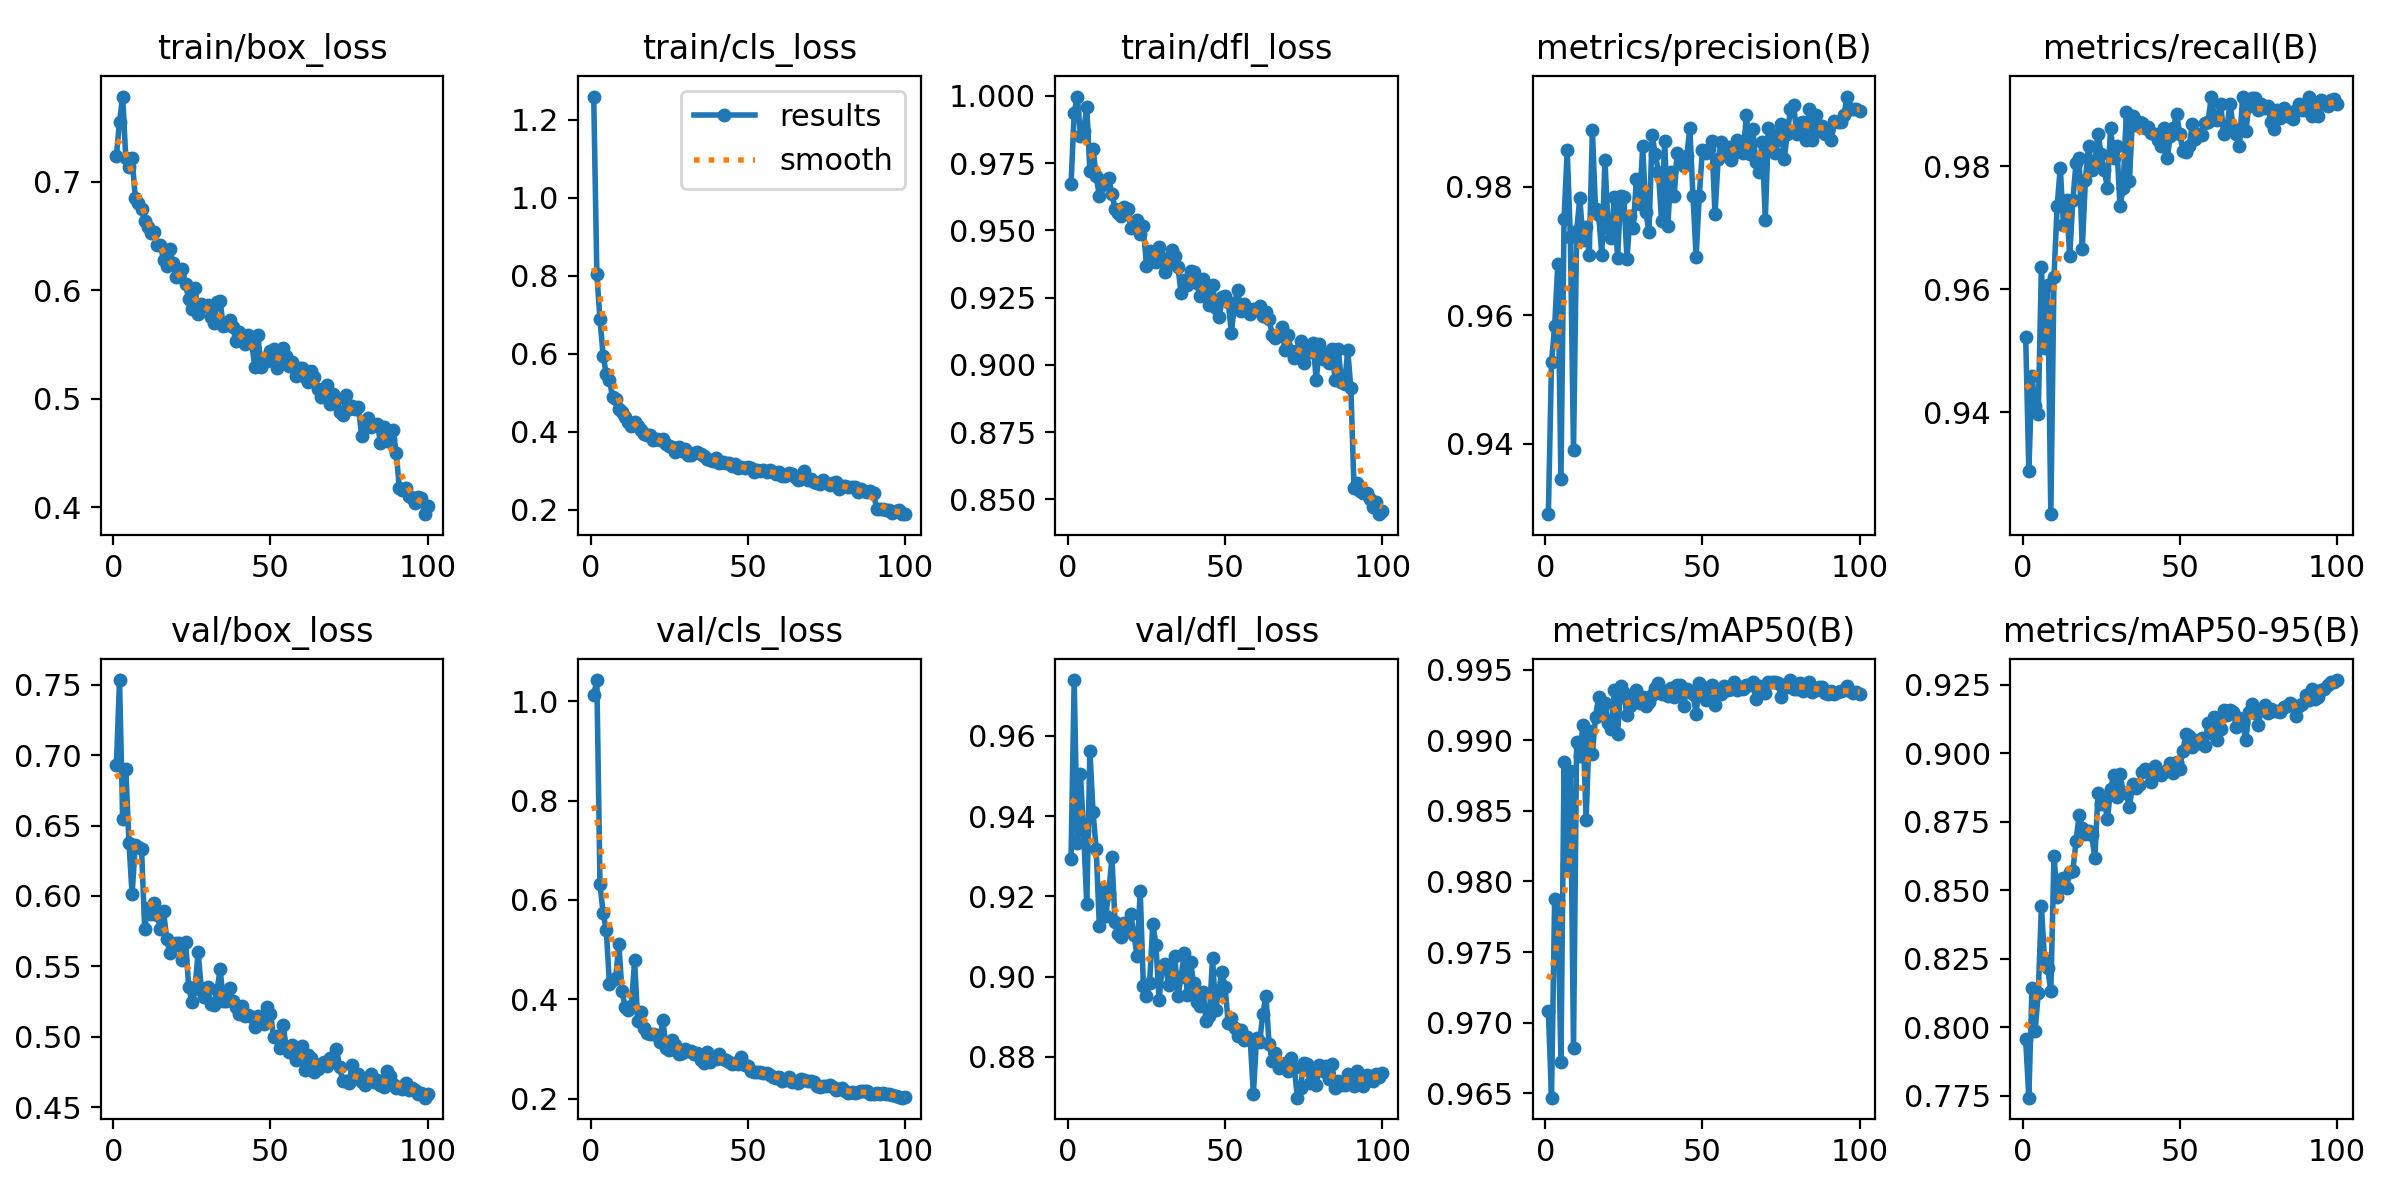


🖼️  验证集检测示例：


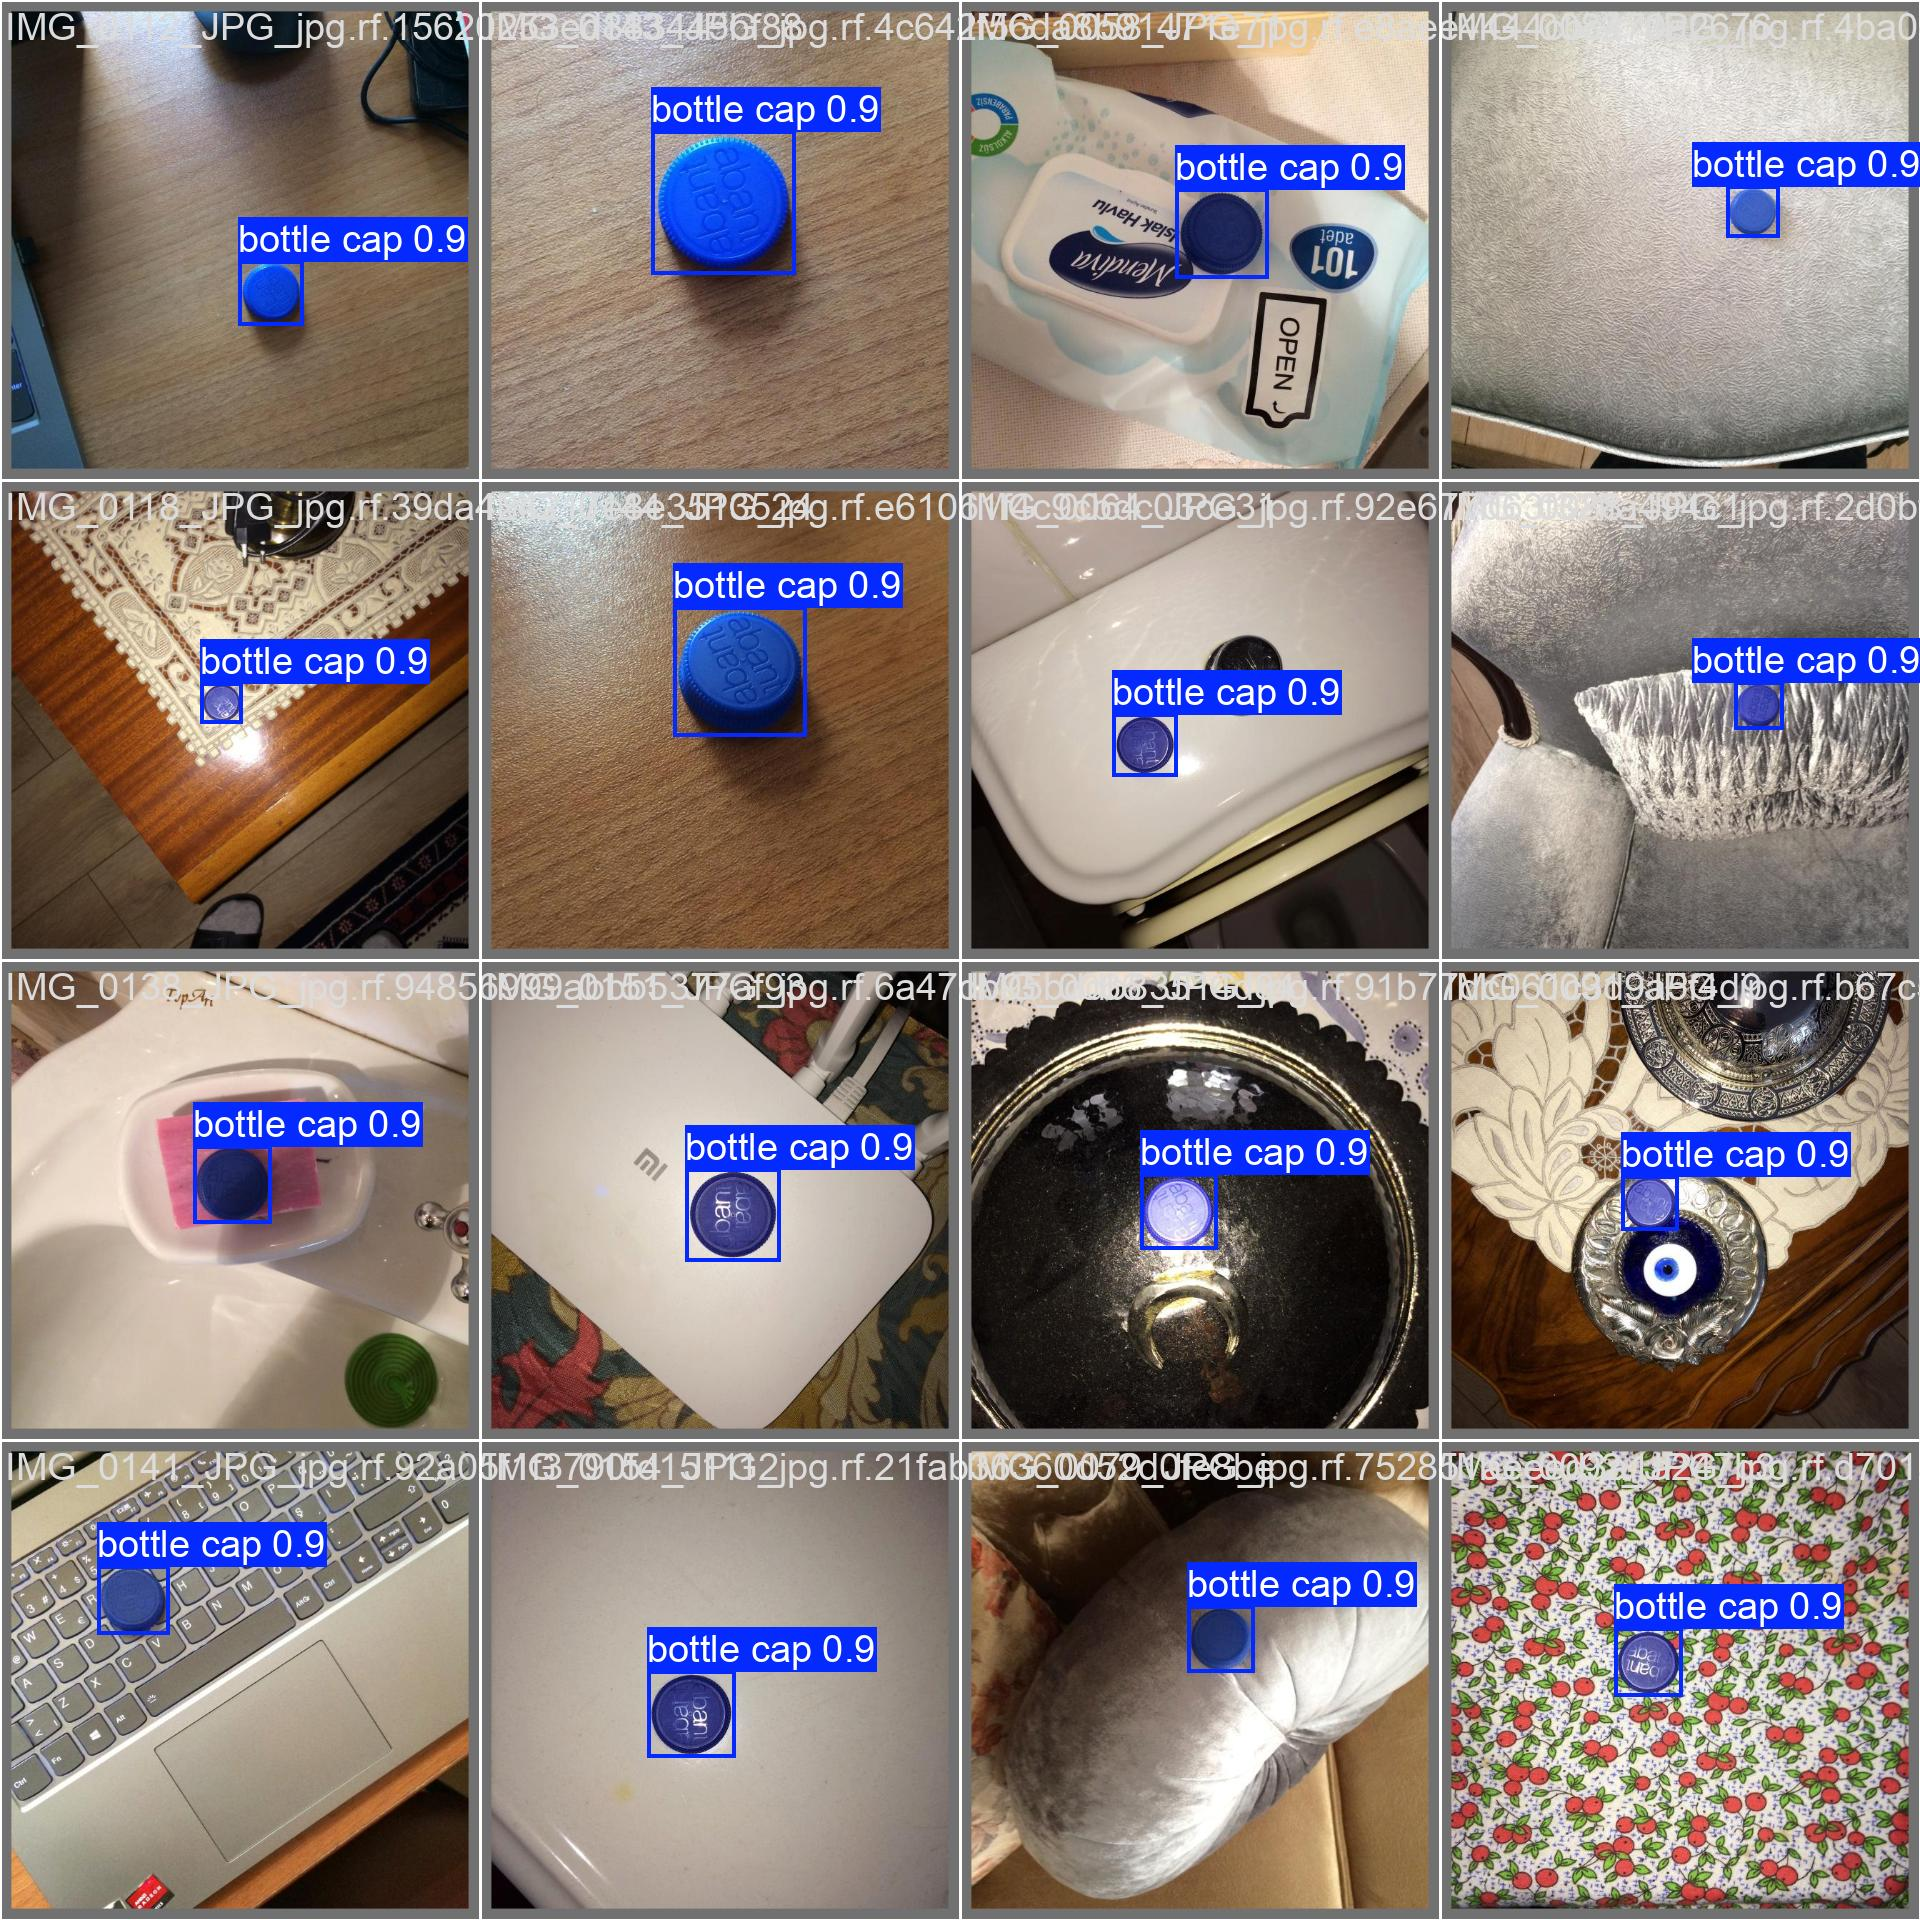


📋 关键指标（来自最佳 Checkpoint）：
   mAP50     : 0.9932
   mAP50-95  : 0.9267
   Precision : 0.9918
   Recall    : 0.9902

💡 mAP50 > 0.7 说明模型基本可用，> 0.85 是工业级水准


In [14]:
from IPython.display import Image, display
import glob

save_dir = results.save_dir
print(f"📊 训练结果目录：{save_dir}\n")

# 显示训练曲线
results_img = os.path.join(save_dir, 'results.png')
if os.path.exists(results_img):
    print("📈 训练曲线：")
    display(Image(results_img, width=900))

# 显示验证集检测示例
val_imgs = glob.glob(os.path.join(save_dir, 'val_batch*.jpg'))
if val_imgs:
    print("\n🖼️  验证集检测示例：")
    display(Image(val_imgs[0], width=900))

# 打印最终指标
print("\n📋 关键指标（来自最佳 Checkpoint）：")
print(f"   mAP50     : {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")
print(f"   mAP50-95  : {results.results_dict.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
print(f"   Precision : {results.results_dict.get('metrics/precision(B)', 'N/A'):.4f}")
print(f"   Recall    : {results.results_dict.get('metrics/recall(B)', 'N/A'):.4f}")
print("\n💡 mAP50 > 0.7 说明模型基本可用，> 0.85 是工业级水准")

## Cell 7 — 导出 ONNX（供 ClearVision DeepLearning 算子使用）

In [17]:
from ultralytics import YOLO
import os
import shutil
import yaml

# 1. 加载最佳模型
best_pt = '/content/runs/detect/yolov8n_train/weights/best.pt'
model = YOLO(best_pt)
print(f"加载模型：{best_pt}")

# 2. 导出 ONNX
print("正在导出 ONNX...")
export_path = model.export(
    format="onnx",
    imgsz=640,              # ← 这里直接写 640（你训练时用的尺寸）
    simplify=True,          # 简化模型，推理更快
    opset=12,               # 常用兼容版本，11/12/13/17 都可以，12 最稳
    dynamic=False           # False = 固定尺寸更快；True = 支持不同 batch 大小
)

# 3. 重命名 + 复制（可选，更好管理）
output_name = "bottle_cap_detector_yolov8n.onnx"   # 你可以改成自己想要的名字
final_onnx = f"/content/{output_name}"
shutil.copy(export_path, final_onnx)

# 4. 显示信息
file_size = os.path.getsize(final_onnx) / 1024 / 1024
print(f"\n✅ ONNX 导出成功")
print(f"文件路径：{final_onnx}")
print(f"文件大小：{file_size:.2f} MB")
print(f"输入尺寸：640 × 640")

# 5. 读取 data.yaml 获取 nc 和 names（可选，更完整的信息）
data_yaml_path = '/content/bottle-cap-y6pzg-1/data.yaml'   # ← 改成你实际的 data.yaml 路径
with open(data_yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

print(f"类别数量：{data_cfg.get('nc')}")
print(f"类别列表：{data_cfg.get('names')}")

加载模型：/content/runs/detect/yolov8n_train/weights/best.pt
正在导出 ONNX...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/yolov8n_train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 0.9s, saved as '/content/runs/detect/yolov8n_train/weights/best.onnx' (11.7 MB)

Export complete (1.3s)
Results saved to /content/runs/detect/yolov8n_train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/yolov8n_train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/yolov8n_train/weights/best.onnx imgsz=640 data=/content/bottle-cap-1/data.yaml  
Visualize:       https://netron.app

✅ ONNX 导出成功
文件路径：/content/bottle_c

## Cell 8 — 下载 ONNX 文件到本地

In [19]:
from google.colab import files

print(f"⬇️  开始下载 {output_name} 到本地...")
print("   浏览器会弹出下载提示，注意查看下载栏。")
files.download(final_onnx)
print("✅ 下载完成！")
print("\n📌 将这个 .onnx 文件放到 ClearVision 项目的模型目录")
print("   然后在 DeepLearning 算子的 ModelPath 参数里填写路径即可。")

⬇️  开始下载 bottle_cap_detector_yolov8n.onnx 到本地...
   浏览器会弹出下载提示，注意查看下载栏。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 下载完成！

📌 将这个 .onnx 文件放到 ClearVision 项目的模型目录
   然后在 DeepLearning 算子的 ModelPath 参数里填写路径即可。


## Cell 9 — （可选）在 Colab 里快速验证模型效果

🖼️  测试图像：IMG_0125_JPG_jpg.rf.6240f6405dcc2f3a46795387878af23c.jpg

image 1/1 /content/bottle-cap-1/test/images/IMG_0125_JPG_jpg.rf.6240f6405dcc2f3a46795387878af23c.jpg: 640x640 1 bottle cap, 7.9ms
Speed: 2.0ms preprocess, 7.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/predictions/test


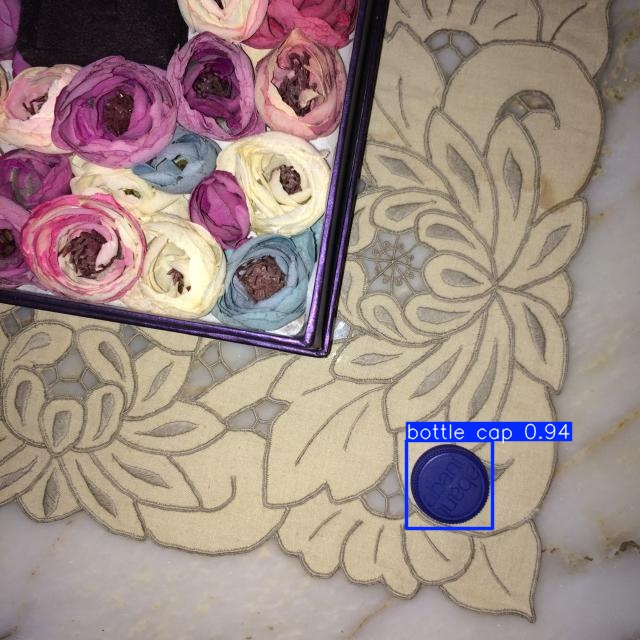


检测到 1 个目标：
   - bottle cap  置信度: 93.77%


In [21]:
import os
import glob
import random
from IPython.display import Image as IPImage, display
import cv2
from ultralytics import YOLO

# 仅从 test 集取样，避免 test 缺失时回退 valid 导致评估泄漏
test_dir = os.path.join(dataset.location, 'test', 'images')
all_imgs = glob.glob(os.path.join(test_dir, '*.jpg')) + \
           glob.glob(os.path.join(test_dir, '*.png'))

if not os.path.isdir(test_dir):
    print("⚠️ 未找到 test 集目录，已跳过评估，避免回退 valid 造成评估泄漏。")
elif not all_imgs:
    print("⚠️ test 集目录存在但无图像，已跳过评估。")
else:
    VIS_SAMPLE_SEED = RANDOM_SEED if 'RANDOM_SEED' in globals() else 42
    sample_rng = random.Random(VIS_SAMPLE_SEED)
    sample_img = sample_rng.choice(sorted(all_imgs))
    print(f"🖼️  测试图像：{os.path.basename(sample_img)} (seed={VIS_SAMPLE_SEED})")

    # 用训练好的最佳模型推理（用 .pt，方便可视化）
    infer_model = YOLO(os.path.join(results.save_dir, 'weights', 'best.pt'))
    pred_results = infer_model.predict(
        source=sample_img,
        conf=0.25,
        save=True,
        project='/content/predictions',
        name='test',
        exist_ok=True
    )

    # 显示检测结果
    pred_img = glob.glob('/content/predictions/test/*.jpg') + \
               glob.glob('/content/predictions/test/*.png')
    if pred_img:
        display(IPImage(pred_img[0], width=700))

    # 打印检测到的目标
    result = pred_results[0]
    print(f"\n检测到 {len(result.boxes)} 个目标：")
    for box in result.boxes:
        cls_name = data_cfg['names'][int(box.cls)]
        conf = float(box.conf)
        print(f"   - {cls_name}  置信度: {conf:.2%}")

---

## 附：常见问题

**Q：训练中断了怎么办？**  
Colab 免费版有时会断开连接。可以从 Cell 5 重新运行，加上 `resume=True` 参数：
```python
model.train(..., resume=True)
```

**Q：显存不足（CUDA out of memory）怎么办？**  
回到 Cell 3，把 `BATCH_SIZE` 从 16 改为 8，或把 `IMG_SIZE` 从 640 改为 320。

**Q：mAP 很低（< 0.5）怎么办？**  
增加训练轮数（`EPOCHS` 改为 100），或换更大的模型（`MODEL_SIZE` 改为 `yolov8s`）。

**Q：换一个数据集怎么用这个 Notebook？**  
只需修改 Cell 3 里的 `WORKSPACE`、`PROJECT`、`VERSION` 三个值，其余 Cell 不用改。

**Q：ONNX 文件放到 ClearVision 的哪里？**  
放到项目的模型目录（如 `Models/` 文件夹），然后在 `DeepLearning` 算子的 `ModelPath` 参数填写完整路径即可。